In [1]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from project.models import EDM

In [2]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

Using: mps


In [3]:
%cd ..
PATH = os.path.join("data", "sprites")
BATCH_SIZE = 32

/Users/daanwichmann/PycharmProjects/BSc Thesis


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=0.5,
        std=0.5
    )  # Normalize image between [-1, 1]
])

In [5]:
data = datasets.ImageFolder(
    root=PATH,
    transform=transform,
)
loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True)

In [6]:
image, y = data[50]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7882353].


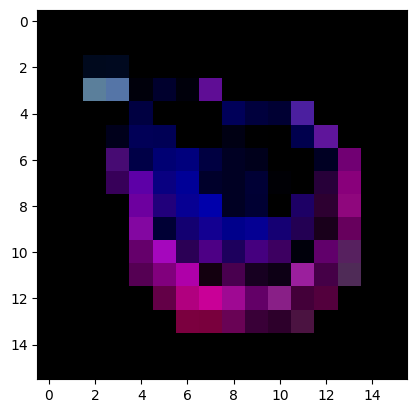

In [7]:
plt.imshow(image.permute((1, 2, 0)))
plt.show()

In [8]:
model = EDM(
    image_resolution=image.shape[1],
    image_channels=image.shape[0],
).to(device)

In [9]:
x = model.heun_sampler(1)

  0%|          | 0/35 [00:00<?, ?it/s]/Users/daanwichmann/PycharmProjects/BSc Thesis/project/models/edm.py:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return (1 / 4) * torch.log(torch.tensor(sigma, device=self._device))
100%|██████████| 35/35 [00:20<00:00,  2.10it/s]


In [ ]:
model.train(10, loader)

Epoch process:   0%|          | 1/2794 [00:15<11:42:48, 15.10s/it]